**Import packages**

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes=True)                                 # To get the different different colors
pd.set_option('display.max_columns',None)                        # To display the max columns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score,roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Read the preprocessed data**

In [101]:
data=pd.read_csv("Preprocessed_data.csv")
data

,Unnamed: 0,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Avg Monthly Long Distance Charges,Multiple Lines,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,0,0,37,1,0,34.827662,-118.999073,2,9,5,42.39,0,0,16.0,0,1,0,1,1,0,0,1,1,1,1,65.60,593.30,0.00,0,381.51,974.81,1
1,1,1,46,0,0,34.162515,-118.203869,0,9,5,10.69,1,0,10.0,0,0,0,0,0,1,1,0,0,0,1,-4.00,542.40,38.33,10,96.21,610.28,1
2,2,1,50,0,0,33.645672,-117.922613,0,4,4,33.65,0,2,30.0,0,0,1,0,0,0,0,1,0,1,0,73.90,280.85,0.00,0,134.60,415.45,0
3,3,1,78,1,0,38.014457,-122.115432,1,13,3,27.82,0,2,4.0,0,1,1,0,1,1,0,1,0,1,0,98.00,1237.85,0.00,0,361.66,1599.51,0
4,4,0,75,1,0,34.227846,-119.079903,3,3,5,7.38,0,2,11.0,0,0,0,1,1,0,0,1,0,1,1,83.90,267.40,0.00,0,22.14,289.54,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4830,7036,0,53,0,0,36.807595,-118.901544,0,1,4,42.09,0,2,9.0,0,0,0,0,0,0,0,1,0,1,1,70.15,70.15,0.00,0,42.09,112.24,0
4831,7038,0,20,0,0,32.759327,-116.997260,0,13,3,46.68,0,1,59.0,1,0,0,1,0,0,1,1,1,0,1,55.15,742.90,0.00,0,606.84,1349.74,1
4832,7039,1,40,1,0,37.734971,-120.954271,1,22,3,16.20,1,2,17.0,0,0,0,0,0,1,1,1,0,1,0,85.10,1873.70,0.00,0,356.40,2230.10,0
4833,7040,1,22,0,0,39.108252,-123.645121,0,2,4,18.62,0,1,51.0,0,1,0,0,0,0,0,1,0,1,1,50.30,92.75,0.00,0,37.24,129.99,1


$Step-1$:

**Divide data into input and target data**

In [102]:
# here the target column is Customer Status
x = data.drop('Unnamed: 0',axis=1,inplace=True)
X = data.drop('Customer Status',axis=1)
y = data['Customer Status']

In [103]:
data.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'Latitude',
       'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status'],
      dtype='object')

In [104]:
X.shape, y.shape

((4835, 30), (4835,))

$Step-2$:

**Train-Test-Split**

In [105]:
# test size = 0.2, train data 80% and test data 20% 
# random state=0 will split the data randomly

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(3868, 30)
(967, 30)
(3868,)
(967,)


In [106]:
data.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'Latitude',
       'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status'],
      dtype='object')

$Step-3$:

**Removing the outliers using z-score**

In [107]:
from scipy import stats

# define the columns for which you want to remove outliers

selected_columns = ['Number of Dependents','Number of Dependents','Total Refunds',
                    'Total Extra Data Charges','Total Extra Data Charges','Total Revenue']

# Calculate the Z-scores for the selected columns in the traning data
z_scores = np.abs(stats.zscore(X_train[selected_columns]))

# Set a threshold value for oultliers detection (e.g.. 3)
threshold = 3

# Find the indices of ouliers based on the threshold

outlier_indices = np.where(z_scores > threshold)[0]

# Remove the outliers from the training data
X_train = X_train.drop(X_train.index[outlier_indices])
y_train = y_train.drop(y_train.index[outlier_indices])

In [108]:
print(y_train.shape)
y_train.head()

(3566,)


464     1
3361    1
2394    1
2691    1
1651    1
Name: Customer Status, dtype: int64

**Without Hyperparameter tuning**

$decision$ $Tree$

accuracy is: 74.35
F1 is: 0.81
Precision_dt: 0.82
Recall is: 0.8
              precision    recall  f1-score   support

           0       0.59      0.63      0.61       308
           1       0.82      0.80      0.81       659

    accuracy                           0.74       967
   macro avg       0.71      0.71      0.71       967
weighted avg       0.75      0.74      0.75       967



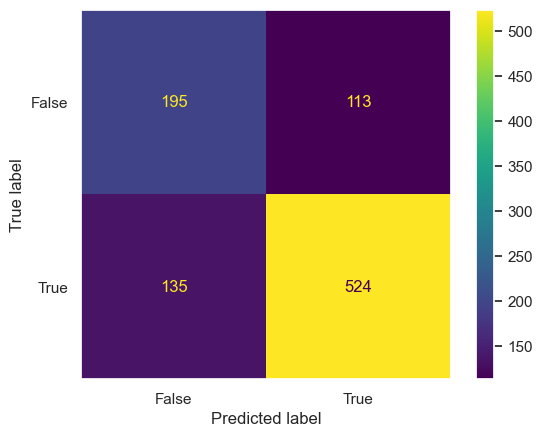

True negative: 195
False positive: 524
False negstive: 135
True positive: 524


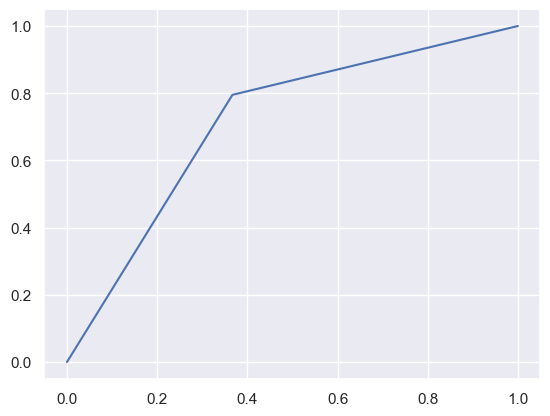

In [143]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

# ========= Step-5: Predicions ===============

y_pred_dt=dtree.predict(X_test)

# ======== Step-6: Metrics ===================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt = round(f1_score(y_test,y_pred_dt),2)
precision_dt = round(precision_score(y_test,y_pred_dt),2)
recall_dt = round(recall_score(y_test,y_pred_dt),2)

print("accuracy is:",acc_dt)
print("F1 is:", f1_dt)
print("Precision_dt:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =========== Step-7: Confusion matrix =================

cmt=confusion_matrix(y_test,y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels=[False,True])

disp.plot()
plt.grid(False)
plt.show()

tn,fp,fn,tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:", tn)
print("False positive:", tp)
print("False negstive:", fn)
print("True positive:", tp)

# ==================Step-8============================

y_dt_pred_prob=dtree.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr, tpr, threshold=roc_curve(y_test,y_dt_pred_prob)
plt.plot(fpr,tpr)

**Without Hyperparameter tuning**

In [116]:
# We are not providing any parameters
# We are using the default parameters

$Decision$ $Tree$

In [117]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier()
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [119]:
y_pred_dt=dtree.predict(X_test)
print(y_pred_dt[:10])
print(y_test.values[:10])

[0 1 1 0 1 1 1 1 0 1]
[0 1 0 0 1 1 1 0 1 1]


In [120]:
acc_dt=round(accuracy_score(y_test,y_pred_dt),2)
acc_dt

0.75

In [134]:
tn,fp,fn,tp = confusion_matrix(y_test,y_pred_dt).ravel()
# TP = 199
# TN = 531
# FP = 128
# FN = 112
print(tn,fp,fn,tp)
print(199+531)
acc=(tn+tp)/(tn+tp+fp+fn)
precision = tp/(tp+fp)
recall=tp/(tp+fn)
f1=(2*precision*recall)/(precision+recall)
print(acc,precision,recall,f1)

193 115 130 529
730
0.7466390899689762 0.8214285714285714 0.802731411229135 0.8119723714504988


In [135]:
print(accuracy_score(y_test,y_pred_dt))
print(precision_score(y_test,y_pred_dt))
print(recall_score(y_test,y_pred_dt))
print(f1_score(y_test,y_pred_dt))

0.7466390899689762
0.8214285714285714
0.802731411229135
0.8119723714504988


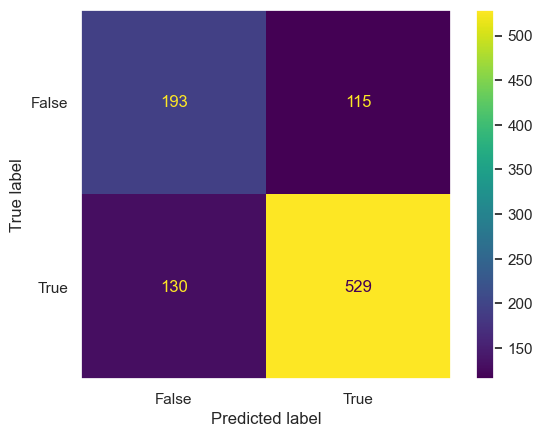

In [137]:
cmt=confusion_matrix(y_test,y_pred_dt)
ConfusionMatrixDisplay(cmt, display_labels = [False, True]).plot()
plt.grid(False)

In [142]:
dtree.predict_proba(X_test)
# col=1 col=2
# col=1  related
# [0.,1.]
# when you pass one observation X_test === no yes
# P(No) = 0
# P(yes) = 1
# Final answer = 1

# No  yes
# 0    1        1: Yes,

# 1: yes,

# No yes
# 1   0         0:No

# 1:yes

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(967, 2))

In [147]:
# Class 0 and class 1
# we need to extract only class-1 prob
dtree.predict_proba(X_test)[:,1]

array([0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
       0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0.,
       0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 1., 0., 0.

In [148]:
# Class 0 and class 1
# we need to extract only class-1 prob
y_pred_prob=dtree.predict_proba(X_test)[:,1]   # TP ====
roc_curve(y_test,y_pred_prob)
# y_score === probability

y_pred_dt=dtree.predict(X_test)
accuracy_score(y_test,y_pred_dt)

0.7435367114788004

**Logistic Regression**

C:\Users\SIDDESH R M\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy is: 75.9
F1 is: 0.82
Precision_dt: 0.82
Recall is: 0.82


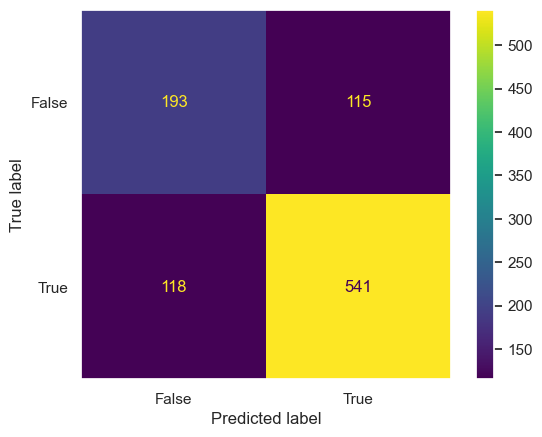

True negative: 193
False positive: 115
False negative: 118
True positive: 541


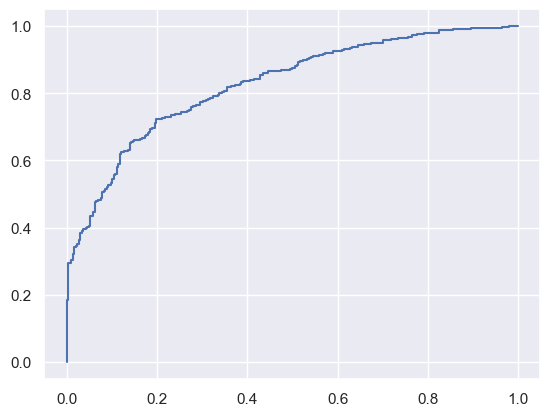

In [151]:
# ================= Step-4: Train the Modle ========================

from sklearn.linear_model import LogisticRegression
logtree=LogisticRegression()
logtree.fit(X_train, y_train)

# ================ Step-5: predictions =============================

y_pred_log=logtree.predict(X_test)

# =============== Step-6: Metrics ====================================
acc_log = round(accuracy_score(y_test,y_pred_log)*100,2)
f1_log = round(f1_score(y_test,y_pred_log),2)
precision_log = round(precision_score(y_test,y_pred_log),2)
recall_log = round(recall_score(y_test,y_pred_log),2)

print("accuracy is:",acc_log)
print("F1 is:", f1_log)
print("Precision_dt:",precision_log)
print("Recall is:",recall_log)

# ======================= Step-7: Confusion matrix ===================
cmt=confusion_matrix(y_test, y_pred_log)

disp=ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels= [False,True])
disp.plot()
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_log).ravel()
print("True negative:",tn)
print("False positive:",fp)
print("False negative:",fn)
print("True positive:",tp)

#================Step-8: ROC-AUC curve====================

y_log_pred_prob=logtree.predict_proba(X_test)[:,1]    # Class-1 probabilities
fpr, tpr, threshold=roc_curve(y_test,y_log_pred_prob)
plt.plot(fpr,tpr)
plt.show()


**Naive_bayes**

accuracy is: 72.6
F1 is: 0.78
Precision_dt: 0.87
Recall is: 0.71


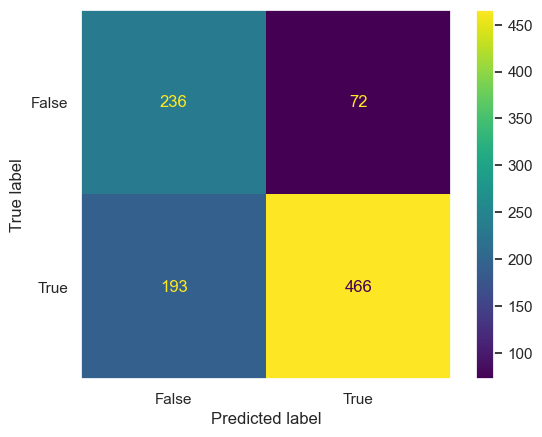

True negative: 236
False positive: 72
False negative: 193
True positive: 466


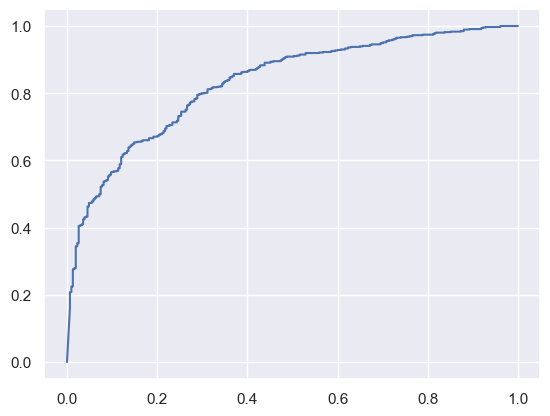

In [152]:
# ================= Step-4: Train the Modle ========================

from sklearn.naive_bayes import GaussianNB
NBtree=GaussianNB()
NBtree.fit(X_train, y_train)

# ================ Step-5: predictions =============================

y_pred_NB=NBtree.predict(X_test)

# =============== Step-6: Metrics ====================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, class_likelihood_ratios
acc_NB = round(accuracy_score(y_test,y_pred_NB)*100,2)
f1_NB = round(f1_score(y_test,y_pred_NB),2)
precision_NB = round(precision_score(y_test,y_pred_NB),2)
recall_NB = round(recall_score(y_test,y_pred_NB),2)

print("accuracy is:",acc_NB)
print("F1 is:", f1_NB)
print("Precision_dt:",precision_NB)
print("Recall is:",recall_NB)

# ======================= Step-7: Confusion matrix ===================
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cmt=confusion_matrix(y_test, y_pred_NB)

disp=ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels= [False,True])
disp.plot()
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_NB).ravel()
print("True negative:",tn)
print("False positive:",fp)
print("False negative:",fn)
print("True positive:",tp)

#================Step-8: ROC-AUC curve====================

y_NB_pred_prob=NBtree.predict_proba(X_test)[:,1]    # Class-1 probabilities
fpr, tpr, threshold=roc_curve(y_test,y_NB_pred_prob)
plt.plot(fpr,tpr)
plt.show()


accuracy is: 70.84
F1 is: 0.8
Precision_dt: 0.76
Recall is: 0.83


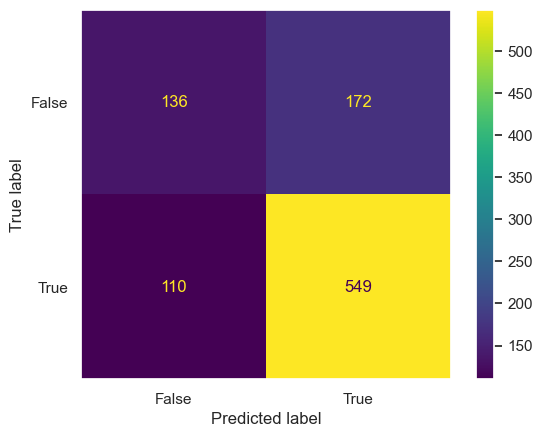

True negative: 136
False positive: 172
False negative: 110
True positive: 549


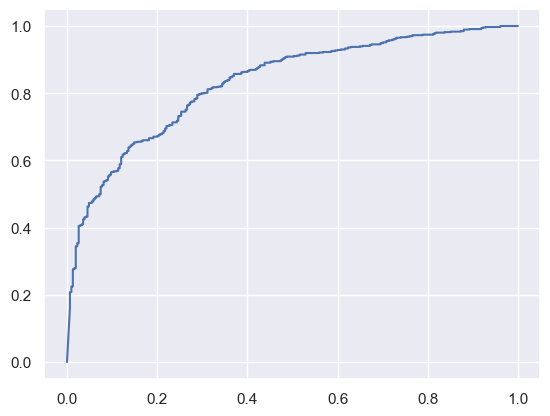

In [153]:
# ================= Step-4: Train the Modle ========================

from sklearn.neighbors import KNeighborsClassifier
KNNtree=KNeighborsClassifier()
KNNtree.fit(X_train, y_train)

# ================ Step-5: predictions =============================

y_pred_KNN=KNNtree.predict(X_test)

# =============== Step-6: Metrics ====================================
acc_KNN = round(accuracy_score(y_test,y_pred_KNN)*100,2)
f1_KNN = round(f1_score(y_test,y_pred_KNN),2)
precision_KNN = round(precision_score(y_test,y_pred_KNN),2)
recall_KNN = round(recall_score(y_test,y_pred_KNN),2)

print("accuracy is:",acc_KNN)
print("F1 is:", f1_KNN)
print("Precision_dt:",precision_KNN)
print("Recall is:",recall_KNN)

# ======================= Step-7: Confusion matrix ===================
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cmt=confusion_matrix(y_test, y_pred_KNN)

disp=ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels= [False,True])
disp.plot()
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_KNN).ravel()
print("True negative:",tn)
print("False positive:",fp)
print("False negative:",fn)
print("True positive:",tp)

#================Step-8: ROC-AUC curve====================

y_KNN_pred_prob=NBtree.predict_proba(X_test)[:,1]    # Class-1 probabilities
fpr, tpr, threshold=roc_curve(y_test,y_KNN_pred_prob)
plt.plot(fpr,tpr)
plt.show()


accuracy is: 70.84
F1 is: 0.8
Precision_dt: 0.76
Recall is: 0.83


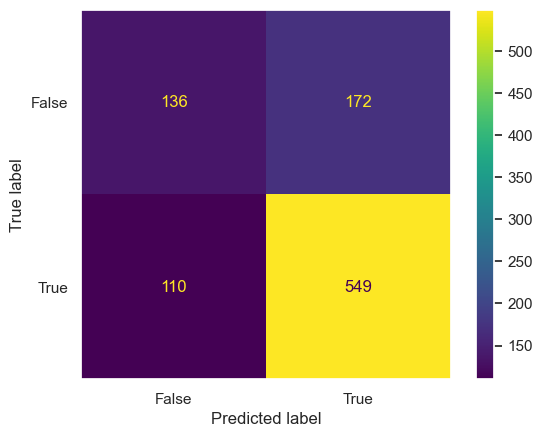

True negative: 136
False positive: 172
False negative: 110
True positive: 549


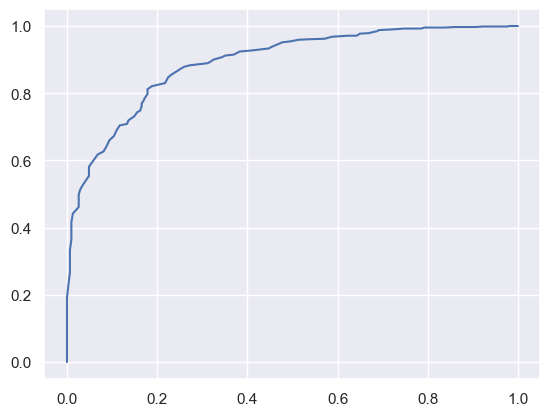

In [154]:
# ================= Step-4: Train the Modle ========================

from sklearn.ensemble import RandomForestClassifier
RFtree=RandomForestClassifier()
RFtree.fit(X_train, y_train)

# ================ Step-5: predictions =============================

y_pred_RF=KNNtree.predict(X_test)

# =============== Step-6: Metrics ====================================
acc_RF = round(accuracy_score(y_test,y_pred_RF)*100,2)
f1_RF = round(f1_score(y_test,y_pred_RF),2)
precision_RF = round(precision_score(y_test,y_pred_RF),2)
recall_RF = round(recall_score(y_test,y_pred_RF),2)

print("accuracy is:",acc_RF)
print("F1 is:", f1_RF)
print("Precision_dt:",precision_RF)
print("Recall is:",recall_RF)

# ======================= Step-7: Confusion matrix ===================
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cmt=confusion_matrix(y_test, y_pred_RF)

disp=ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels= [False,True])
disp.plot()
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_RF).ravel()
print("True negative:",tn)
print("False positive:",fp)
print("False negative:",fn)
print("True positive:",tp)

#================Step-8: ROC-AUC curve====================

y_RF_pred_prob=RFtree.predict_proba(X_test)[:,1]    # Class-1 probabilities
fpr, tpr, threshold=roc_curve(y_test,y_RF_pred_prob)
plt.plot(fpr,tpr)
plt.show()
